# Hydroponics Analytics Platform

## Notebook 02 – Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to explore the hydroponics dataset, identify patterns, relationships, trends, and anomalies using statistical analysis and data visualization. The findings will support data-driven decisions for improving hydroponic system performance.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Makes plots appear inside the notebook
%matplotlib inline

## Step 2 — Load Dataset

In [2]:
df = pd.read_excel("C:/Users/Hp/Downloads/Hydroponics_Analytics_Dataset_10_Days.xlsx")

### Convert Timestamp

In [3]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [4]:
df.head()

,Timestamp,pH,TDS_ppm,Air_Temperature_C,Water_Temperature_C,Humidity_pct,Water_Level_pct,Water_Pump,Nutrient_Pump,Humidifier,Exhaust_Fan,Alert
0,2026-03-01 00:00:00,6.16,709,26.1,23.9,62,100,OFF,ON,OFF,OFF,Low TDS
1,2026-03-01 01:00:00,6.26,704,26.2,24.3,65,98,OFF,ON,OFF,OFF,Low TDS
2,2026-03-01 02:00:00,6.15,718,25.9,23.6,65,96,OFF,OFF,OFF,OFF,Normal
3,2026-03-01 03:00:00,6.22,715,25.5,23.3,62,94,OFF,OFF,OFF,OFF,Normal
4,2026-03-01 04:00:00,6.26,707,25.9,23.8,64,92,OFF,ON,OFF,OFF,Low TDS


## Phase 1 — Understanding Numerical Variables
### Objective

Understand the distribution and behavior of all numerical variables.

### Numeric Columns

In [5]:
numerical_columns = [
    "pH",
    "TDS_ppm",
    "Air_Temperature_C",
    "Water_Temperature_C",
    "Humidity_pct",
    "Water_Level_pct"
]

df[numerical_columns].describe()

,pH,TDS_ppm,Air_Temperature_C,Water_Temperature_C,Humidity_pct,Water_Level_pct
count,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,6.314458,721.545833,30.072917,27.858750,63.850000,70.812500
std,0.084416,7.545537,3.050368,2.722771,2.583015,14.781047
min,6.120000,702.000000,25.500000,23.300000,58.000000,36.000000
25%,6.250000,716.000000,27.600000,25.500000,62.000000,59.000000
50%,6.320000,722.000000,29.200000,27.200000,64.000000,70.500000
75%,6.370000,727.000000,32.800000,30.650000,66.000000,83.000000
max,6.470000,738.000000,37.500000,32.000000,69.000000,100.000000


## Phase 2 — Line Charts (Time-Series)

### pH Trend

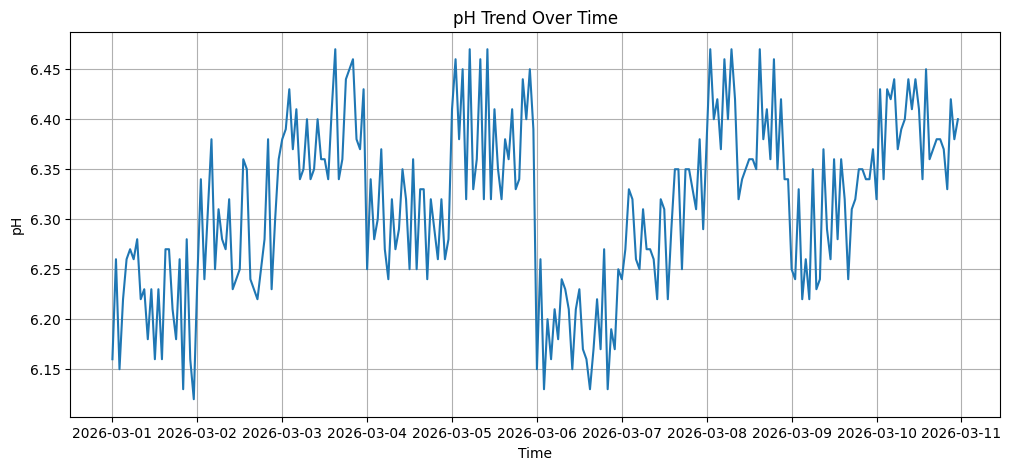

In [6]:
plt.figure(figsize=(12,5))

plt.plot(df["Timestamp"], df["pH"])

plt.title("pH Trend Over Time")
plt.xlabel("Time")
plt.ylabel("pH")

plt.grid(True)

plt.show()

pH remained relatively stable throughout the monitoring period with only minor fluctuations around the recommended operating range.

Stable pH indicates effective nutrient solution management and reduces the need for corrective dosing.

## Phase 3 — Histograms

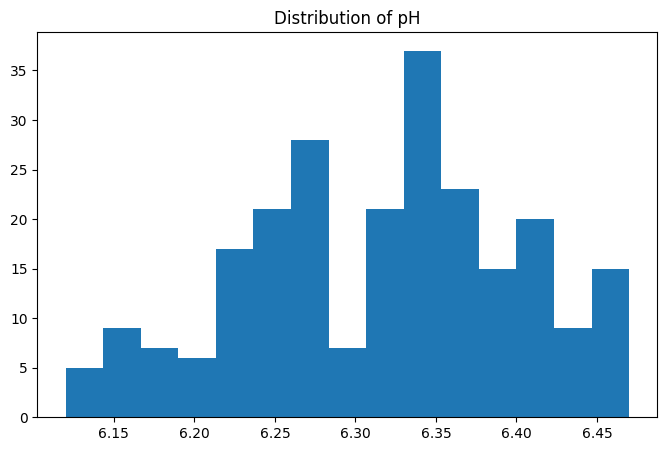

In [7]:
plt.figure(figsize=(8,5))

plt.hist(df["pH"], bins=15)

plt.title("Distribution of pH")

plt.show()

## Phase 4 — Boxplots

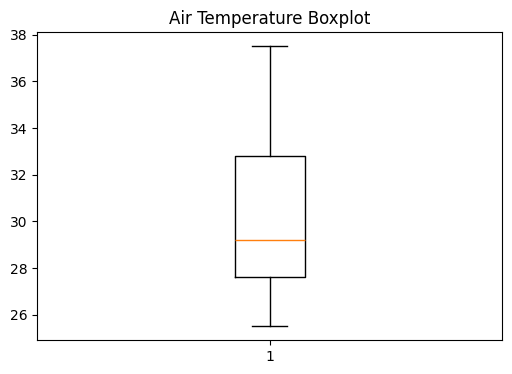

In [8]:
plt.figure(figsize=(6,4))

plt.boxplot(df["Air_Temperature_C"])

plt.title("Air Temperature Boxplot")

plt.show()

## Phase 5 — Correlation Analysis

In [9]:
correlation = df[numerical_columns].corr()

correlation

,pH,TDS_ppm,Air_Temperature_C,Water_Temperature_C,Humidity_pct,Water_Level_pct
pH,1.000000,0.126357,0.015875,0.007229,0.258676,-0.184094
TDS_ppm,0.126357,1.000000,0.059016,0.085496,0.294891,0.007899
Air_Temperature_C,0.015875,0.059016,1.000000,0.985022,-0.598144,-0.319389
Water_Temperature_C,0.007229,0.085496,0.985022,1.000000,-0.577606,-0.288633
Humidity_pct,0.258676,0.294891,-0.598144,-0.577606,1.000000,0.104795
Water_Level_pct,-0.184094,0.007899,-0.319389,-0.288633,0.104795,1.000000


## Phase 6 — Heatmap

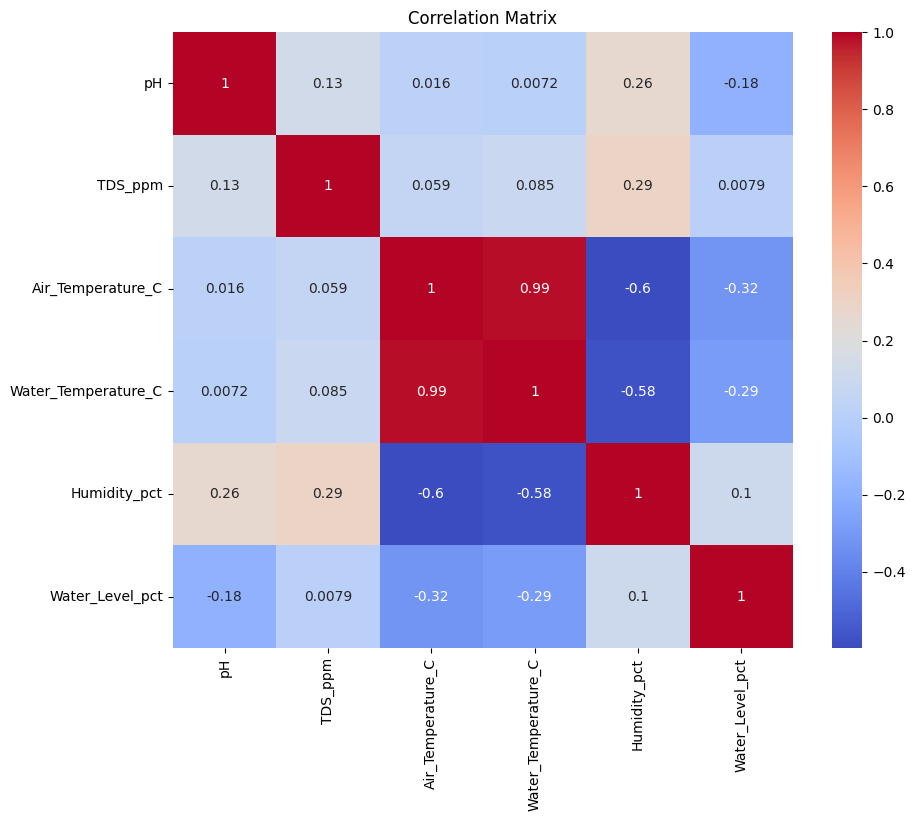

In [10]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

### Air temperature shows a negative relationship with humidity, indicating that higher temperatures are associated with drier environmental conditions.

## Phase 7 — Alerts

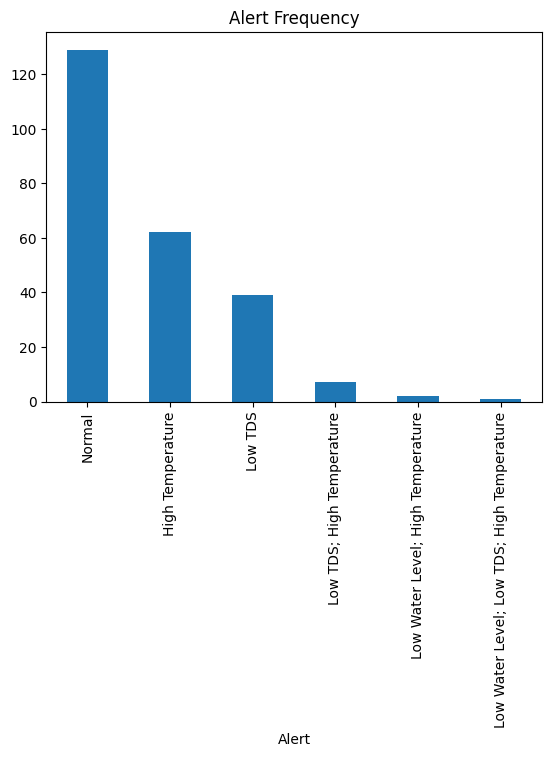

In [11]:
df["Alert"].value_counts().plot(
    kind="bar"
)

plt.title("Alert Frequency")

plt.show()

## Phase 8 — Actuator Analysis

<Axes: xlabel='Water_Pump'>

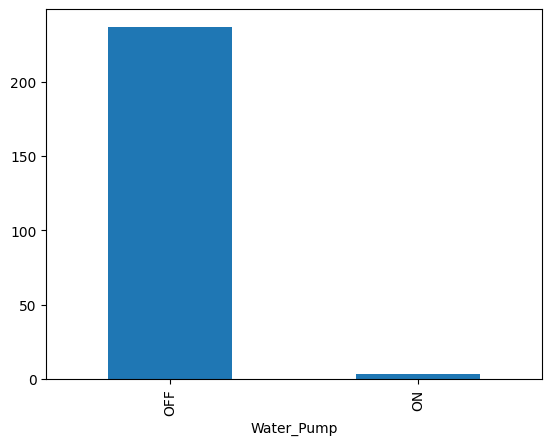

In [12]:
df["Water_Pump"].value_counts().plot(kind="bar")

## Phase 9 — Daily Analysis

In [13]:
df["Date"] = df["Timestamp"].dt.date

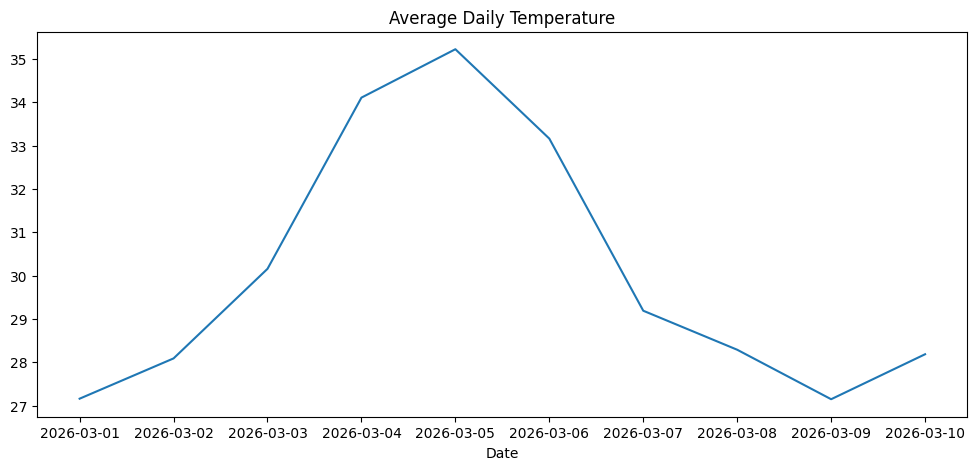

In [14]:
daily_temperature = df.groupby("Date")["Air_Temperature_C"].mean()

daily_temperature.plot(figsize=(12,5))

plt.title("Average Daily Temperature")

plt.show()

## Phase 10 — Hourly Analysis

### Question 1: Which hour is hottest?

In [15]:
# Extract hour from timestamp
df["Hour"] = df["Timestamp"].dt.hour

# Average temperature for each hour
hourly_temp = df.groupby("Hour")["Air_Temperature_C"].mean()

# Display the hottest hour
print(hourly_temp.idxmax())
print(hourly_temp.max())

12
32.07


### The hour with the highest average air temperature is 12 with an average temperature of 32.07 °C.

### During this hour, the hydroponic system is most susceptible to heat stress. Automatic ventilation or exhaust fan operation should be prioritized during this period.

### Question 2: Which hour has the lowest humidity?

In [16]:
hourly_humidity = df.groupby("Hour")["Humidity_pct"].mean()

print(hourly_humidity.idxmin())
print(hourly_humidity.min())

7
62.9


The minimum average humidity occurs at 7.

Since humidity is lowest during this period, activating the humidifier proactively could help maintain optimal growing conditions.

### Question 3: When are pumps most active?

In [17]:
pump_activity = df.groupby("Hour")["Water_Pump"].apply(lambda x: (x == "ON").sum())

print(pump_activity)
print("Most Active Hour:", pump_activity.idxmax())

Hour
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    1
22    1
23    1
Name: Water_Pump, dtype: int64
Most Active Hour: 21


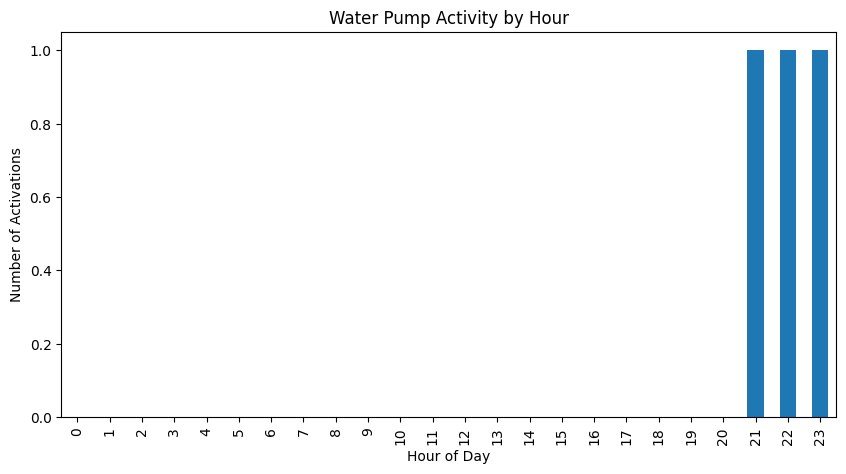

In [19]:
pump_activity.plot(kind="bar", figsize=(10,5))
plt.title("Water Pump Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Activations")
plt.show()

### Phase 11 – Final Observations

### Final Observations
1. The dataset contains 240 hourly observations collected over a 10-day monitoring period.
2. No missing values or duplicate records were found, indicating good data quality.
3. The pH remained within the recommended hydroponic range (approximately 6.1–6.5) throughout the monitoring period, suggesting stable nutrient solution conditions.
4. Air temperature showed daily fluctuations and reached its highest values during the afternoon, which triggered the exhaust fan more frequently.
5. Humidity generally decreased during periods of elevated temperature, indicating an inverse relationship between these two environmental parameters.
6. Water level gradually declined over time and automatically recovered after water pump activation, demonstrating effective automated reservoir management.
7. Nutrient pump activation occurred only when TDS values approached the lower threshold, indicating efficient nutrient dosing.
8. The exhaust fan was the most frequently activated actuator, reflecting the system's response to elevated ambient temperatures.
9. Most sensor readings remained within acceptable operating limits, resulting in a predominance of normal system conditions.
10. The automation logic successfully maintained environmental parameters within suitable ranges for hydroponic crop cultivation, reducing the need for manual intervention.